In [1]:
STUDENT = 'Đinh Quốc Bảo - 6351071006'

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn import tree, metrics
from sklearn.naive_bayes import GaussianNB

In [4]:
df = pd.read_csv('winequality-red.csv')

In [22]:
print(STUDENT)
df.info()

Đinh Quốc Bảo - 6351071006
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1596 entries, 0 to 1595
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1596 non-null   float64
 1   volatile acidity      1596 non-null   float64
 2   citric acid           1596 non-null   float64
 3   residual sugar        1596 non-null   float64
 4   chlorides             1596 non-null   float64
 5   free sulfur dioxide   1596 non-null   float64
 6   total sulfur dioxide  1596 non-null   float64
 7   density               1596 non-null   float64
 8   pH                    1596 non-null   float64
 9   sulphates             1596 non-null   float64
 10  alcohol               1596 non-null   float64
 11  quality               1596 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 149.8 KB


In [23]:
print(STUDENT)
df.head().T

Đinh Quốc Bảo - 6351071006


,0,1,2,3,4
fixed acidity,7.4000,7.8000,7.800,11.200,7.4000
volatile acidity,0.7000,0.8800,0.760,0.280,0.7000
citric acid,0.0000,0.0000,0.040,0.560,0.0000
residual sugar,1.9000,2.6000,2.300,1.900,1.9000
chlorides,0.0760,0.0980,0.092,0.075,0.0760
free sulfur dioxide,11.0000,25.0000,15.000,17.000,11.0000
total sulfur dioxide,34.0000,67.0000,54.000,60.000,34.0000
density,0.9978,0.9968,0.997,0.998,0.9978
pH,3.5100,3.2000,3.260,3.160,3.5100
sulphates,0.5600,0.6800,0.650,0.580,0.5600


### Câu 3

Đinh Quốc Bảo - 6351071006


<Axes: >

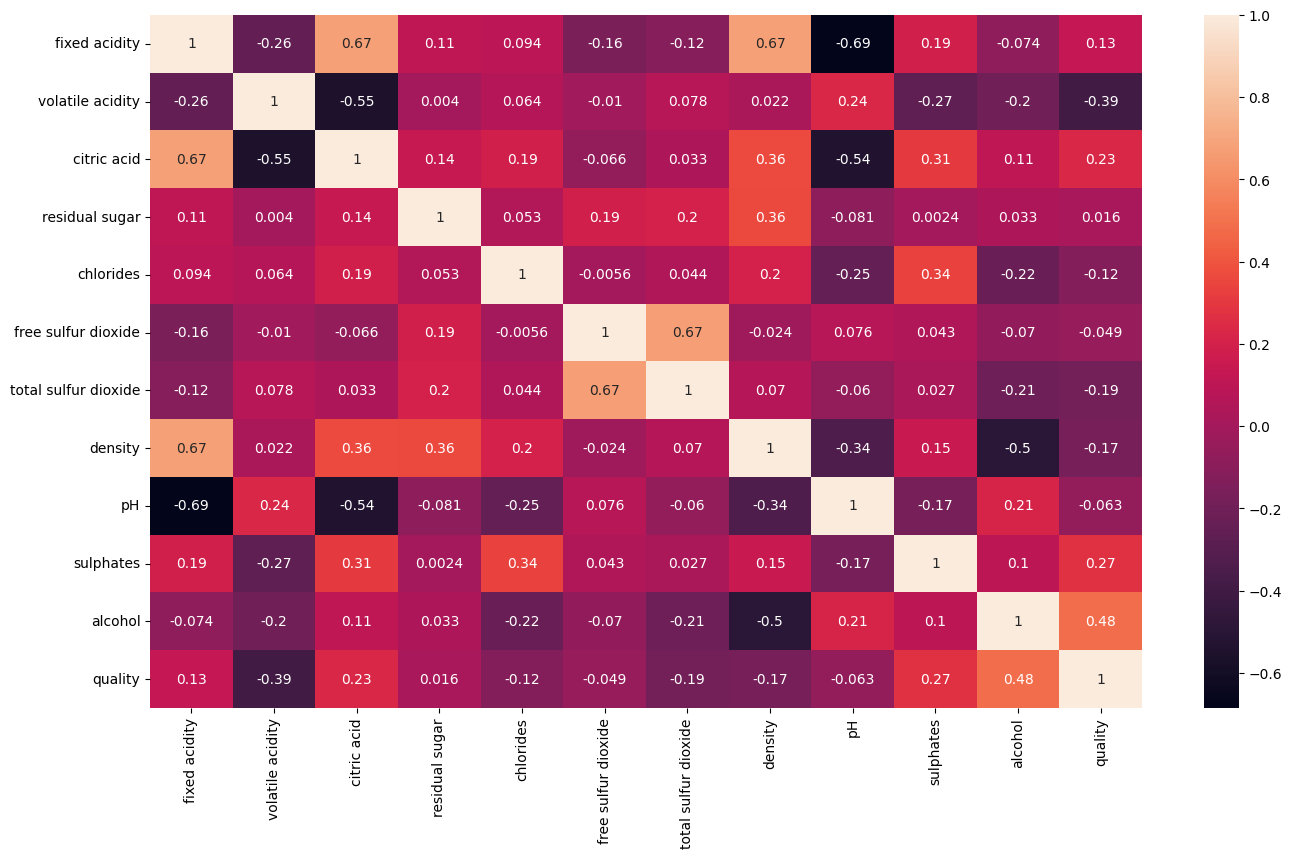

In [7]:
print(STUDENT)
plt.figure(figsize=(16,9))
sns.heatmap(df.corr(method='pearson'), annot=True)

### Câu 4

In [8]:
X = df.drop('quality', axis=1)
y = df['quality']

### Câu 5

In [9]:
print(STUDENT)
X.select_dtypes(exclude=['float64']).columns

Đinh Quốc Bảo - 6351071006


Index([], dtype='object')

### Câu 6

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### Câu 7

In [11]:
clf = tree.DecisionTreeClassifier(criterion="entropy", random_state=0)
clf = clf.fit(X_train, y_train)

In [12]:
tree_pred = clf.predict(X_test)
tree_score = metrics.accuracy_score(y_test, tree_pred)
print(STUDENT)
print("Accuracy:", tree_score)
print("Report:", metrics.classification_report(y_test, tree_pred))

Đinh Quốc Bảo - 6351071006
Accuracy: 0.5887265135699373
Report:               precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.18      0.11      0.14        18
           5       0.67      0.68      0.68       207
           6       0.62      0.54      0.58       193
           7       0.40      0.60      0.48        53
           8       0.29      0.29      0.29         7

    accuracy                           0.59       479
   macro avg       0.36      0.37      0.36       479
weighted avg       0.60      0.59      0.59       479



In [13]:
tree_cm = metrics.confusion_matrix(y_test, tree_pred)

Đinh Quốc Bảo - 6351071006


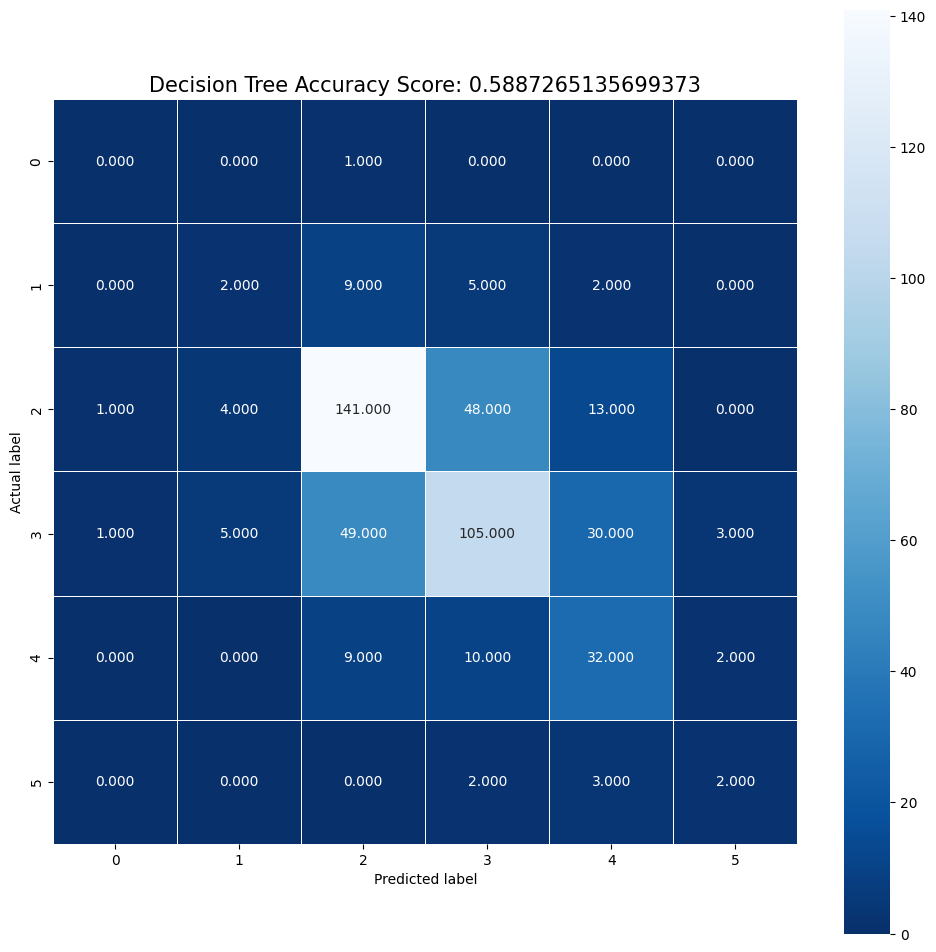

In [14]:
plt.figure(figsize=(12,12))
sns.heatmap(tree_cm, annot=True, fmt=".3f", linewidths=.5, square=True, cmap='Blues_r');
print(STUDENT)
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
title = 'Decision Tree Accuracy Score: {0}'.format(tree_score)
plt.title(title, size=15);

Đinh Quốc Bảo - 6351071006


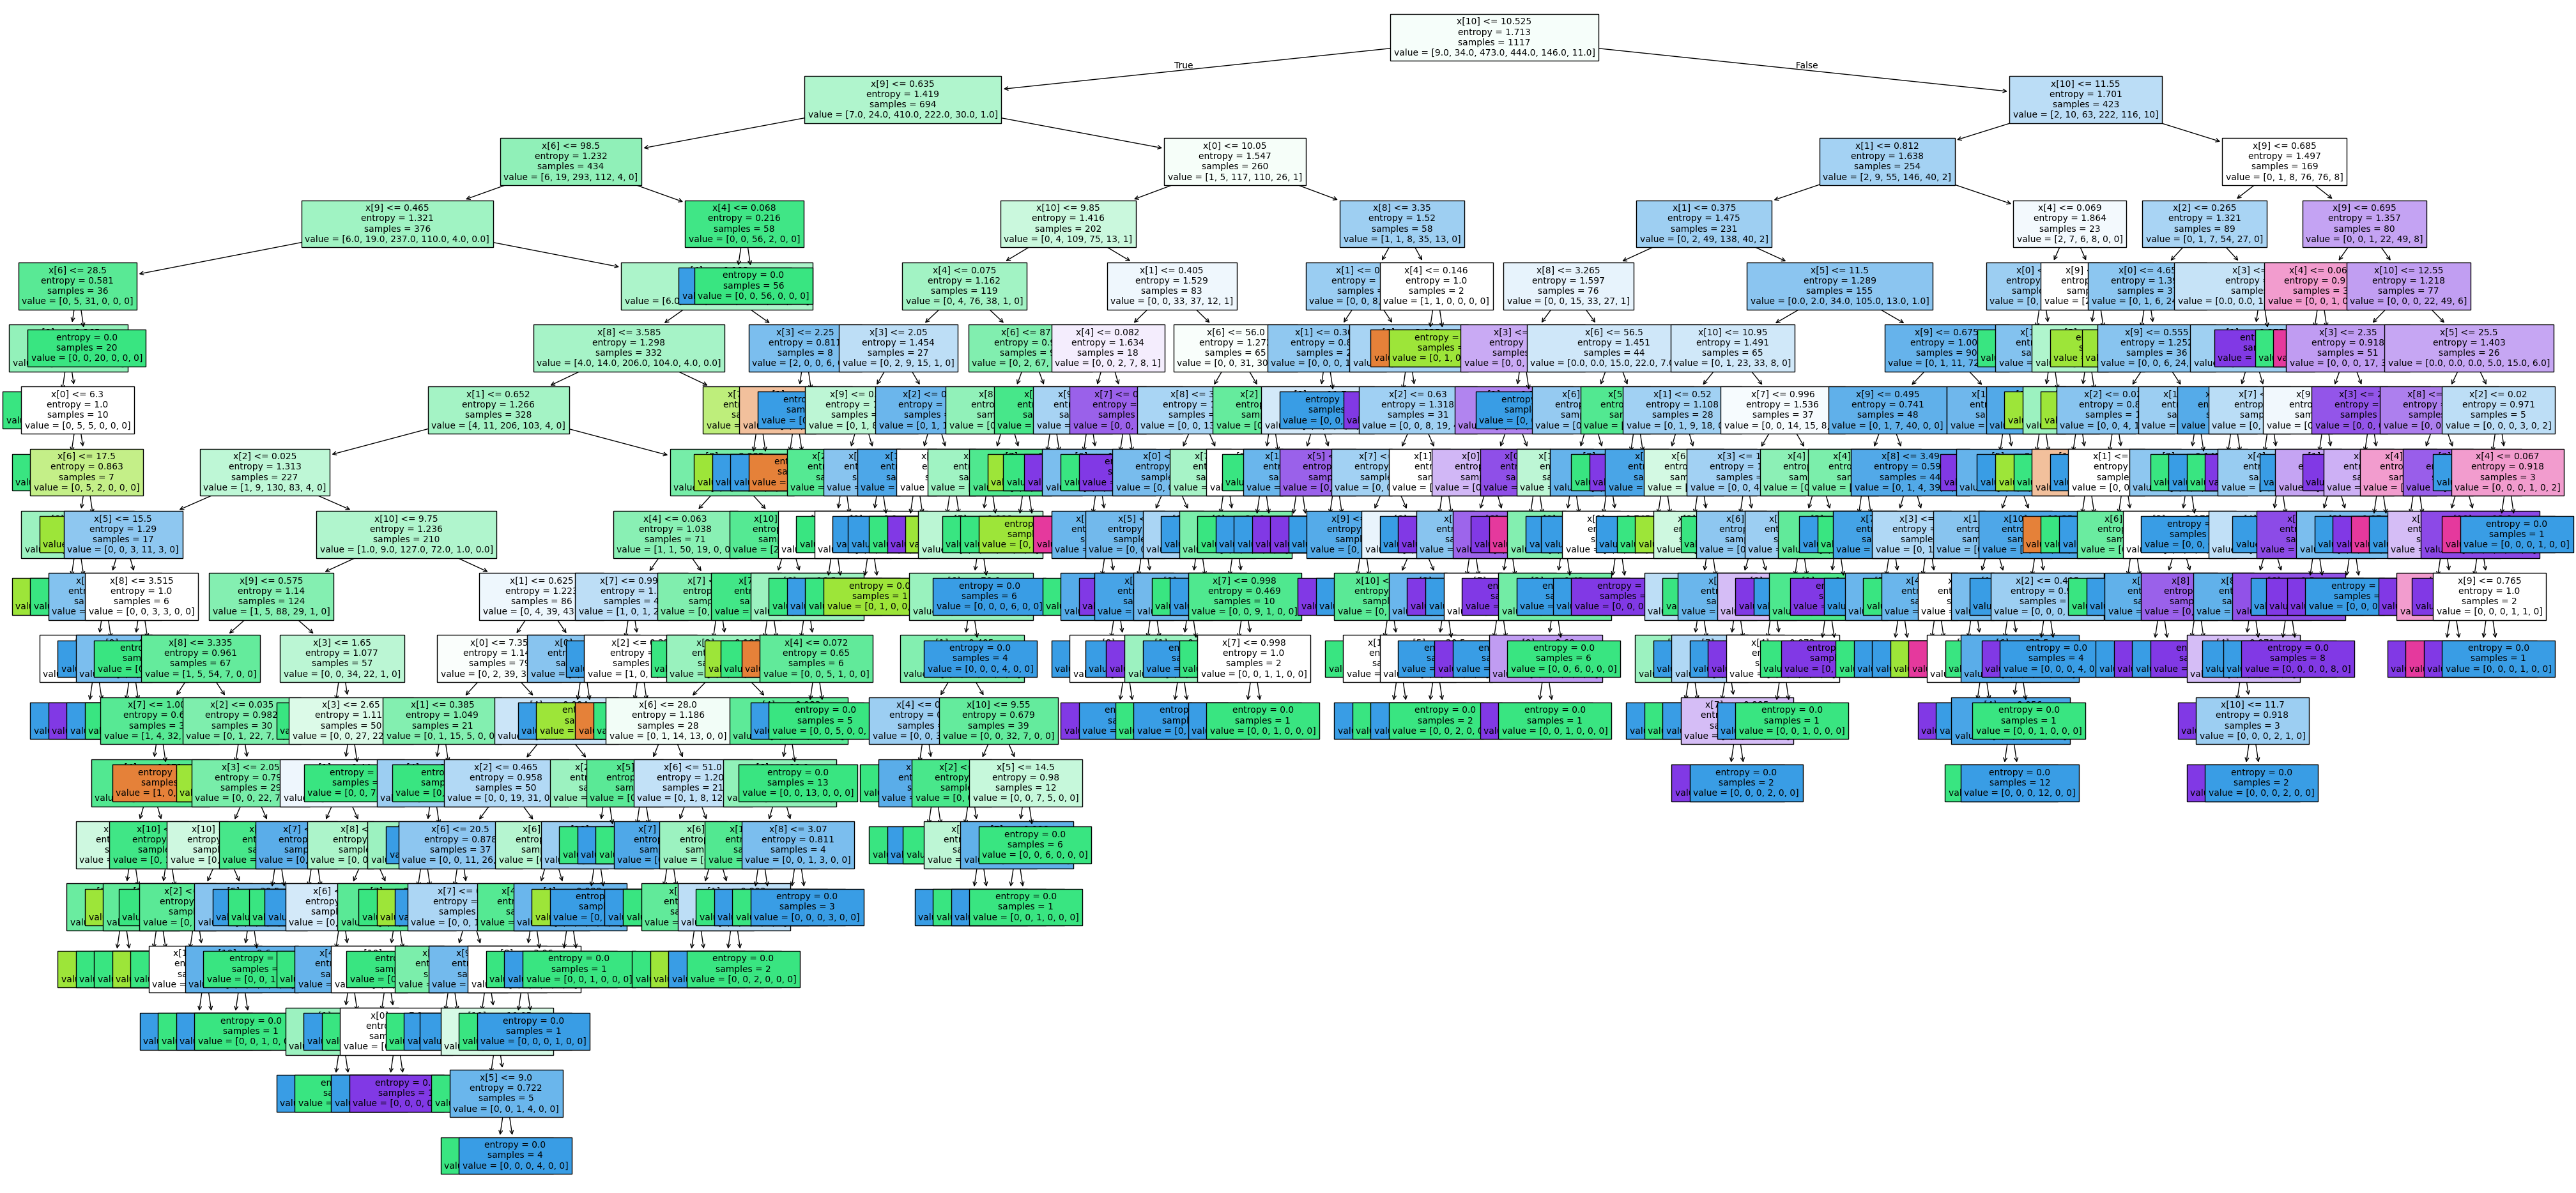

In [15]:
fig, axes = plt.subplots(figsize=(50,24))
tree.plot_tree(clf, filled=True, fontsize=10)
plt.savefig('decision_tree', dpi=100)
print(STUDENT)
plt.show()

### Câu 8

In [16]:
clf = tree.DecisionTreeClassifier(criterion="gini", random_state=0)
clf = clf.fit(X_train, y_train)

In [17]:
tree_pred = clf.predict(X_test)
tree_score = metrics.accuracy_score(y_test, tree_pred)
print(STUDENT)
print("Accuracy:", tree_score)
print("Report:", metrics.classification_report(y_test, tree_pred))

Đinh Quốc Bảo - 6351071006
Accuracy: 0.5720250521920668
Report:               precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.25      0.22      0.24        18
           5       0.67      0.65      0.66       207
           6       0.57      0.54      0.56       193
           7       0.41      0.55      0.47        53
           8       0.29      0.29      0.29         7

    accuracy                           0.57       479
   macro avg       0.37      0.37      0.37       479
weighted avg       0.58      0.57      0.57       479



Đinh Quốc Bảo - 6351071006


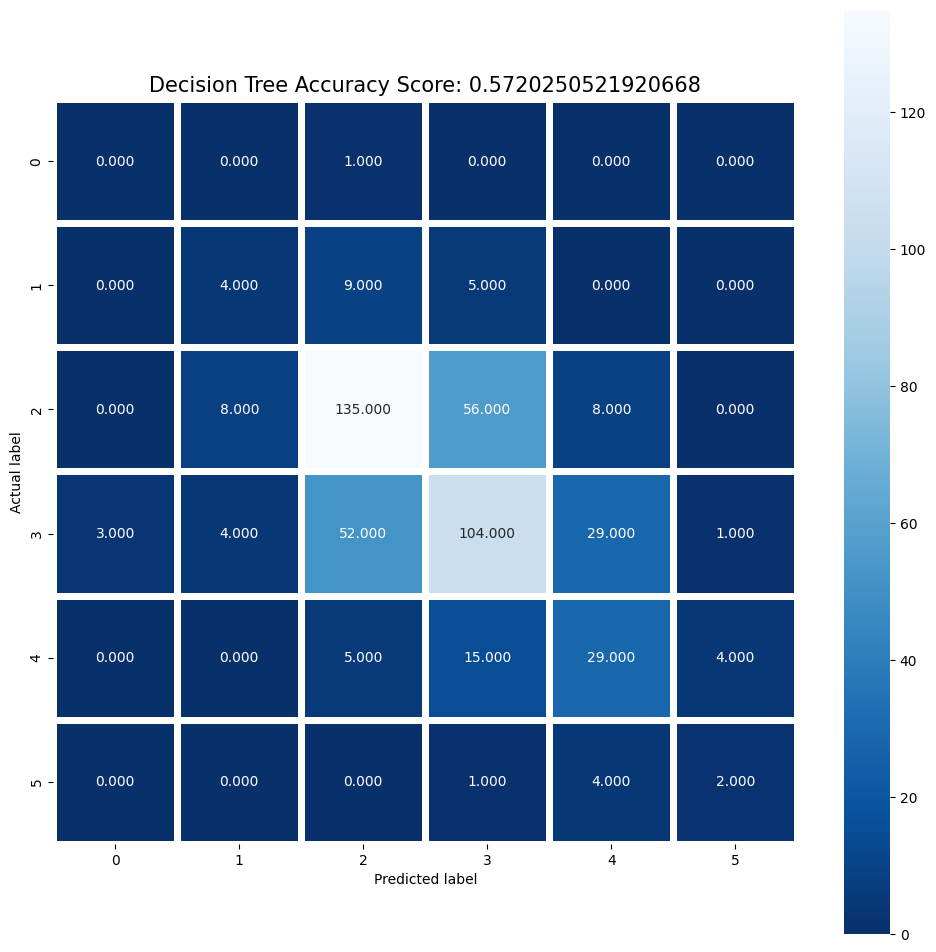

In [18]:
tree_cm = metrics.confusion_matrix(y_test, tree_pred)
plt.figure(figsize=(12,12))
sns.heatmap(tree_cm, annot=True, fmt=".3f", linewidths=5, square=True, cmap='Blues_r');
print(STUDENT)
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
title = 'Decision Tree Accuracy Score: {0}'.format(tree_score)
plt.title(title, size=15);

### Câu 9

In [19]:
gnb = GaussianNB()
bayes_pred = gnb.fit(X_train, y_train).predict(X_test)

In [20]:
bayes_score = metrics.accuracy_score(y_test, bayes_pred)
print(STUDENT)
print("Accuracy:", bayes_score)
print("Report:", metrics.classification_report(y_test, bayes_pred))

Đinh Quốc Bảo - 6351071006
Accuracy: 0.5302713987473904
Report:               precision    recall  f1-score   support

           3       0.33      1.00      0.50         1
           4       0.18      0.17      0.17        18
           5       0.65      0.67      0.66       207
           6       0.51      0.43      0.47       193
           7       0.37      0.55      0.44        53
           8       0.00      0.00      0.00         7

    accuracy                           0.53       479
   macro avg       0.34      0.47      0.37       479
weighted avg       0.54      0.53      0.53       479



Đinh Quốc Bảo - 6351071006


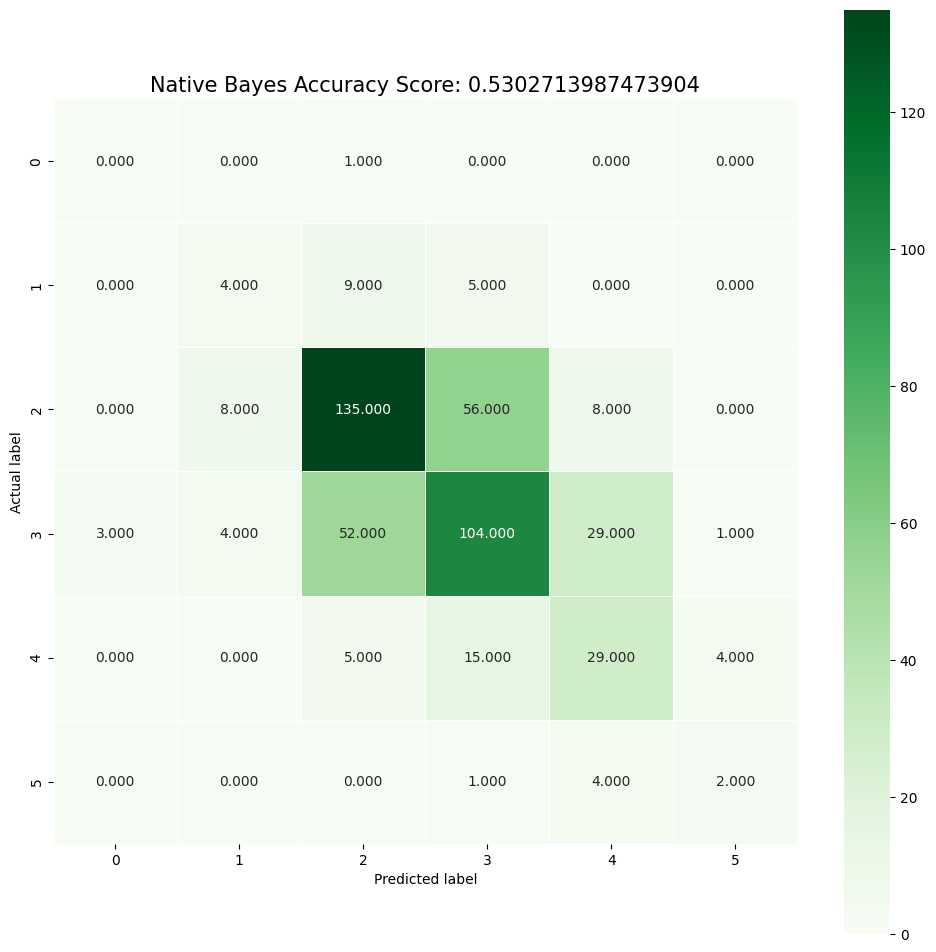

In [21]:
bayes_cm = metrics.confusion_matrix(y_test, bayes_pred)

plt.figure(figsize=(12,12))
sns.heatmap(tree_cm, annot=True, fmt=".3f", linewidths=.5, square=True, cmap='Greens');
print(STUDENT)
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
title = 'Native Bayes Accuracy Score: {0}'.format(bayes_score)
plt.title(title, size=15);

### Câu 10

In [24]:
print(STUDENT)

Đinh Quốc Bảo - 6351071006


- **Decision Tree (Entropy):**  
  - **Accuracy cao nhất: 58.9%** → **tốt nhất trong 3 mô hình**.  
  - F1-score cao nhất ở lớp `5` (0.68), `7` (0.48), `6` (0.58).  
  - Hiệu suất ổn định, ít nhầm lẫn nghiêm trọng.

- **Decision Tree (Gini):**  
  - Accuracy: **57.2%** – gần bằng Entropy.  
  - F1-score tốt ở `5` (0.66), `6` (0.56).  
  - Hiệu suất **gần tương đương** Entropy, **không chênh lệch đáng kể**.

- **Naive Bayes:**  
  - Accuracy: **53.0%** – **thấp nhất**.  
  - Recall cao ở lớp `3` (1.00) nhưng precision thấp (0.33) → **nhiều dương tính giả**.  
  - Lớp `8` hoàn toàn thất bại (F1 = 0.00).  
  - Giả định độc lập **không phù hợp** → hiệu suất kém.

- **So sánh tổng thể:**  
  - **Cây quyết định (Entropy & Gini)** vượt trội Naive Bayes.  
  - **Entropy nhỉnh hơn Gini** một chút (~1.7%).  
  - **Dữ liệu có mẫu nhỏ ở lớp `3`, `8`** → cả 3 mô hình đều yếu ở các lớp hiếm.  
  - **Cần xử lý mất cân bằng** (SMOTE, class_weight) để cải thiện lớp thiểu số.